In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
from src import *

# Filter only objects having one diffusion texture
##### ℹ️ This notebook requires `dataset/objaverse/2-annotations_filtered_by_thumbnails.parquet`. It also requires the `statistics.parquet` file generated by `compute_statistics.py`.
This notebook downloads all the filtered objects and filter them based on the the textures they have.

In [9]:
dataset = ObjaverseDataset3D()
available_uids = set(dataset.paths.keys())
statistics = dataset.statistics
statistics = statistics.loc[list(available_uids.intersection(statistics.index))]
len(statistics)

14715

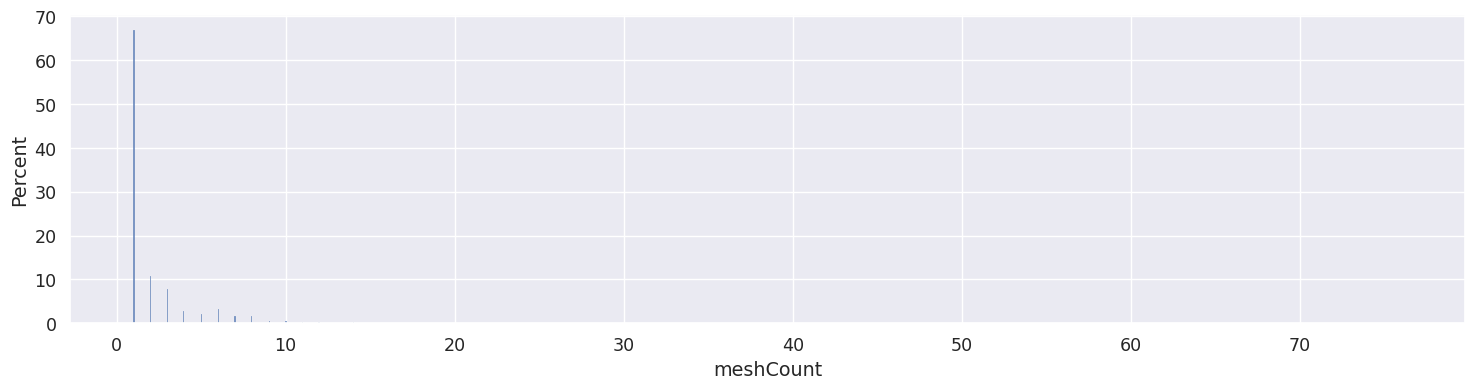

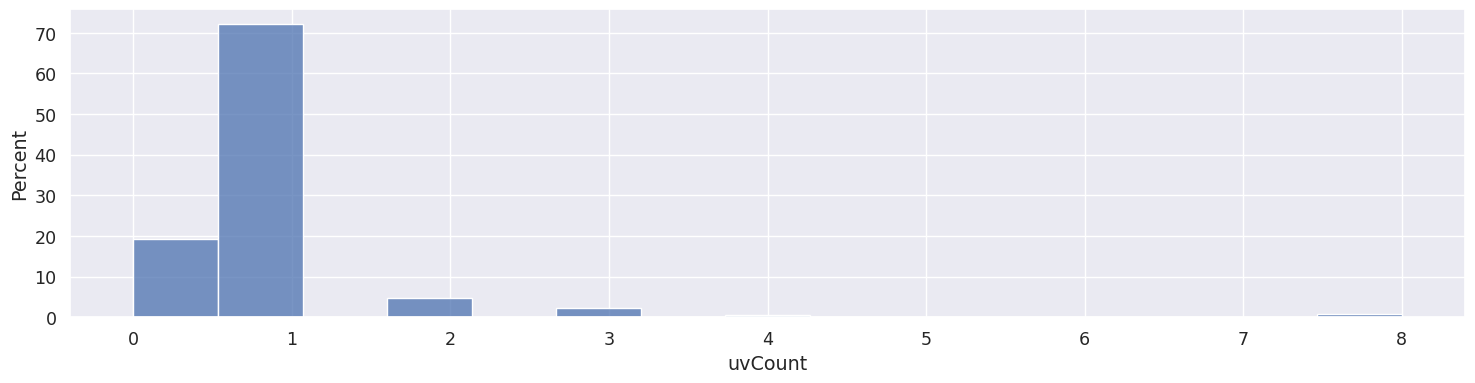

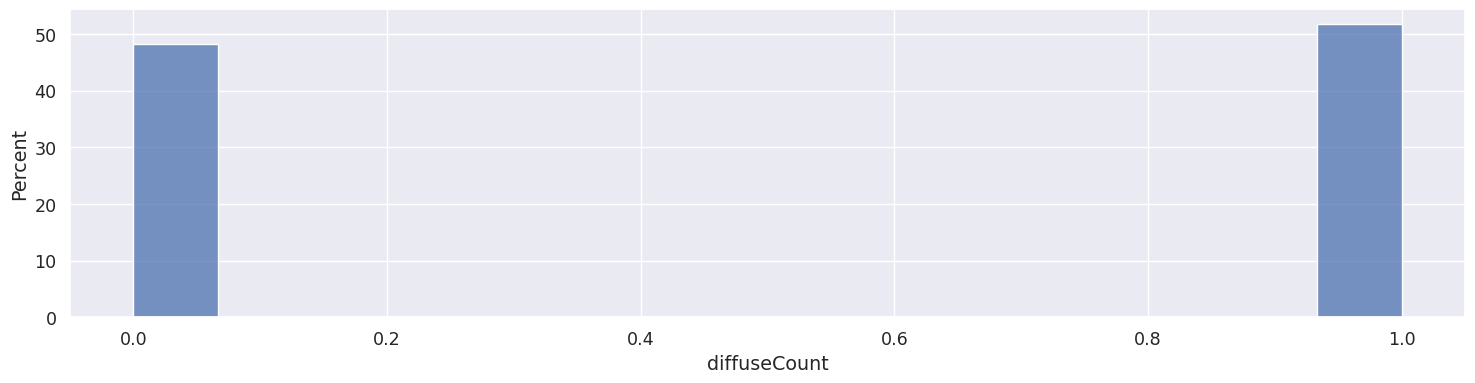

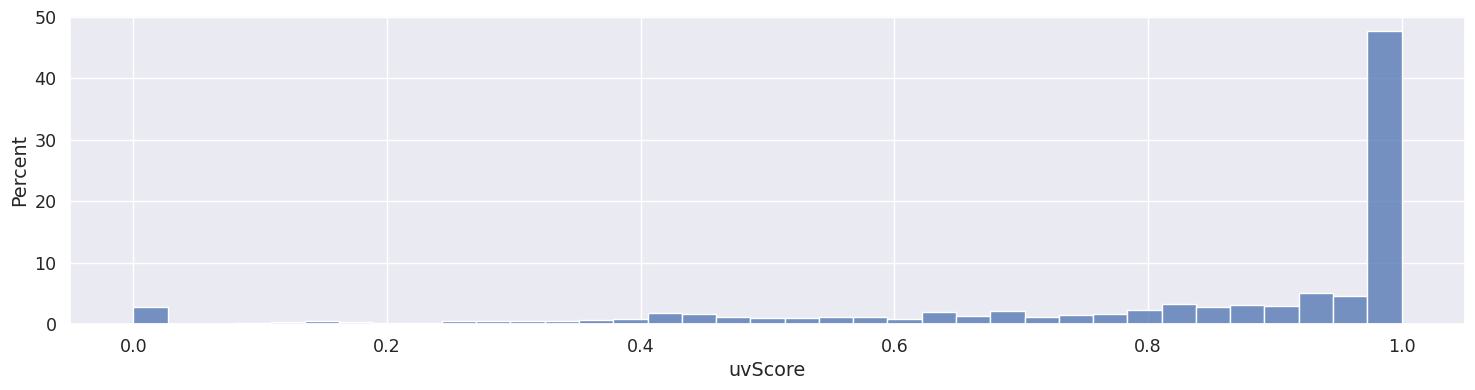

In [10]:
for data in [statistics["meshCount"], statistics["uvCount"], statistics["diffuseCount"], statistics["uvScore"]]:
    plt.figure(figsize=(18, 4))
    sns.histplot(data, stat="percent")
    plt.show()

## How many GLB files have 1 Mesh, 1 UV map and 1 diffuse texture?
Let's check the number of meshes per GLB file first. This takes a random sample of 100 objects. To process the whole dataset, we need a computational node (see [get_statistics.py](get_statistics.py)), otherwise the login node kills the jupyter server after 1000 objects or so.

##### 👉🏼 About $50\%$ of GLB files contain 1 and only one mesh object.

##### 👉🏼 About $75\%$ of them have exactly 1 UV map.

##### 👉🏼 About $60\%$ of them have exactly 1 diffuse texture.
Thus we end up with about $50\% \times 75\% \times 60\% = 22.5\%$ meeting the requirements.

In [12]:
percentage = (statistics["valid"]).sum() / len(statistics) * 100
f"{percentage:.2f}% of GLBs meet the requirements"

'26.10% of GLBs meet the requirements'